In [1]:
import matplotlib as mpl
%matplotlib inline
import matplotlib.pyplot as plt

%config InlineBackend.figure_format = 'retina'

import numpy as np

import matplotlib.pyplot as plt
import matplotlib.animation as animation

import numpy as np

from tqdm import tqdm

import pandas as pd
from pprint import pprint

import seaborn as sns

from matplotlib import rcParams

rcParams["axes.facecolor"] = "FFFFFF"
rcParams["savefig.facecolor"] = "FFFFFF"
rcParams["xtick.direction"] = "in"
rcParams["ytick.direction"] = "in"

rcParams.update({"figure.autolayout": True})

plt.rcParams["figure.figsize"] = (9,9)


In [2]:
def nb_mean(true_r, true_p):
    return true_r * ( 1 - true_p) / true_p
def nb_var(true_t, true_p):
    return nb_mean(true_t, true_p) / true_p

In [44]:
import jax
import jax.numpy as jnp
import jax.random as random
from scipy.stats import nbinom
from jax.example_libraries import optimizers

from fast_negative_binomial import log_negative_binomial2, log_negative_binomial2_jac

nb_grad = jax.jacrev(jax.scipy.stats.nbinom.logpmf, argnums=[1, 2])

# Assume your custom functions negative_binomial2 and negative_binomial2_jac are defined.
# They take arguments (k, m, r) and return, respectively, the log‐pmf and its jacobian (shape: (len(k), 2)).

# Sample 1000 data points from a negative binomial.
key = random.PRNGKey(0)
true_m, true_r = 10.0, 5.0
true_p = true_r / (true_r + true_m)
data = nbinom.rvs(true_r, true_p, size=1000).astype(np.int32)

def loss(params, k):
    r, m = params
    p = r / (r + m)
    likelihood = log_negative_binomial2(k, m, r)
    # print(nb_mean(r, p), nb_var(r, p), -np.sum(np.log(likelihood)), -jnp.sum(jax.scipy.stats.nbinom.logpmf(k, r, p)))
    return -np.sum(likelihood)
    # return -jnp.sum(jax.scipy.stats.nbinom.logpmf(k, r, p))
    # return np.sum(likelihood) - jnp.sum(jax.scipy.stats.nbinom.logpmf(k, r, p))

def loss_grad(params, k):
    r, m = params
    jac = log_negative_binomial2_jac(k, m, r)
    # p = r / (r + m)
    # jac = jnp.vstack(nb_grad(k, r, p)).T
    return -jnp.mean(jac, axis=0)
    # return -jnp.sum(jac, axis = 0)

# Set up the Adam optimizer.
opt_init, opt_update, get_params = optimizers.adam(step_size=1e-2)

# @jax.jit
def step(i, opt_state, k):
    params = get_params(opt_state)
    grads = loss_grad(params, k)
    return opt_update(i, grads, opt_state)

# Initialize parameters (starting guess for m and r).
params0 = jnp.array([10.0, 10.0])
opt_state = opt_init(params0)

# for j in tqdm(range(1000)):

losses = []
ms = []
rs = []

    # Run the optimization for 1000 iterations.
    # for i in tqdm(range(1000)):
for i in tqdm(range(2000)):
    opt_state = step(i, opt_state, data)
    params = get_params(opt_state)
    losses.append(loss(params, data))
    ms.append(params[1])
    rs.append(params[0])

fitted_params = get_params(opt_state)
print("Fitted m: {:.3f}, r: {:.3f}".format(fitted_params[0], fitted_params[1]))


100%|██████████| 2000/2000 [00:00<00:00, 2156.99it/s]

Fitted m: 5.549, r: 9.850


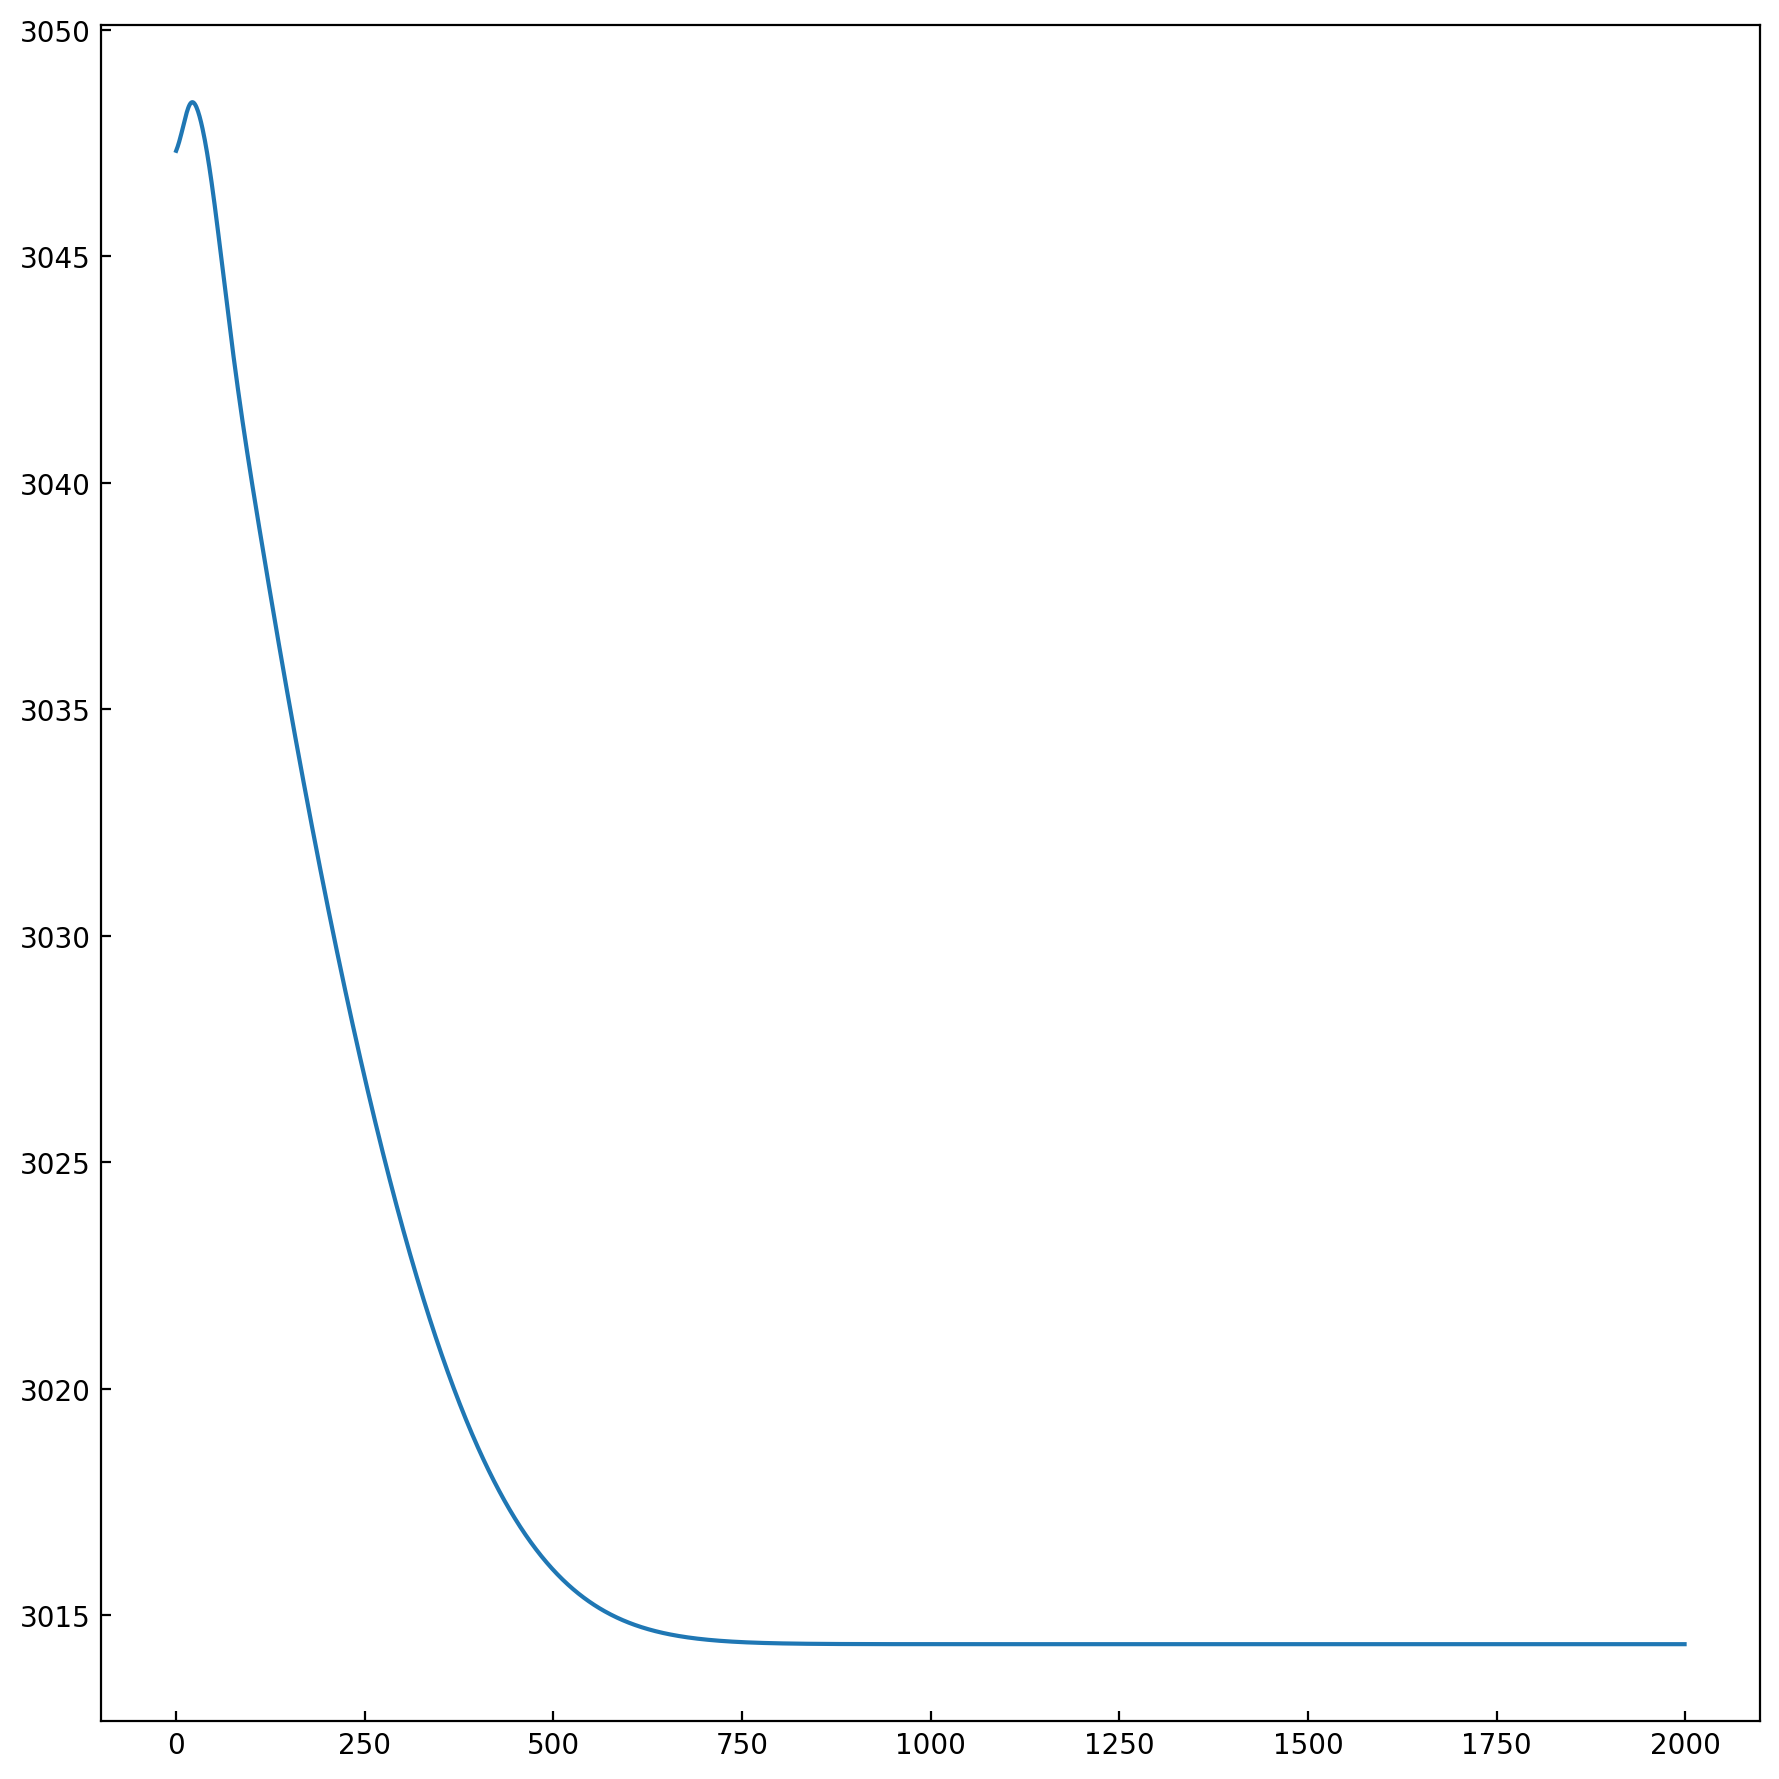

In [13]:
plt.plot(losses)

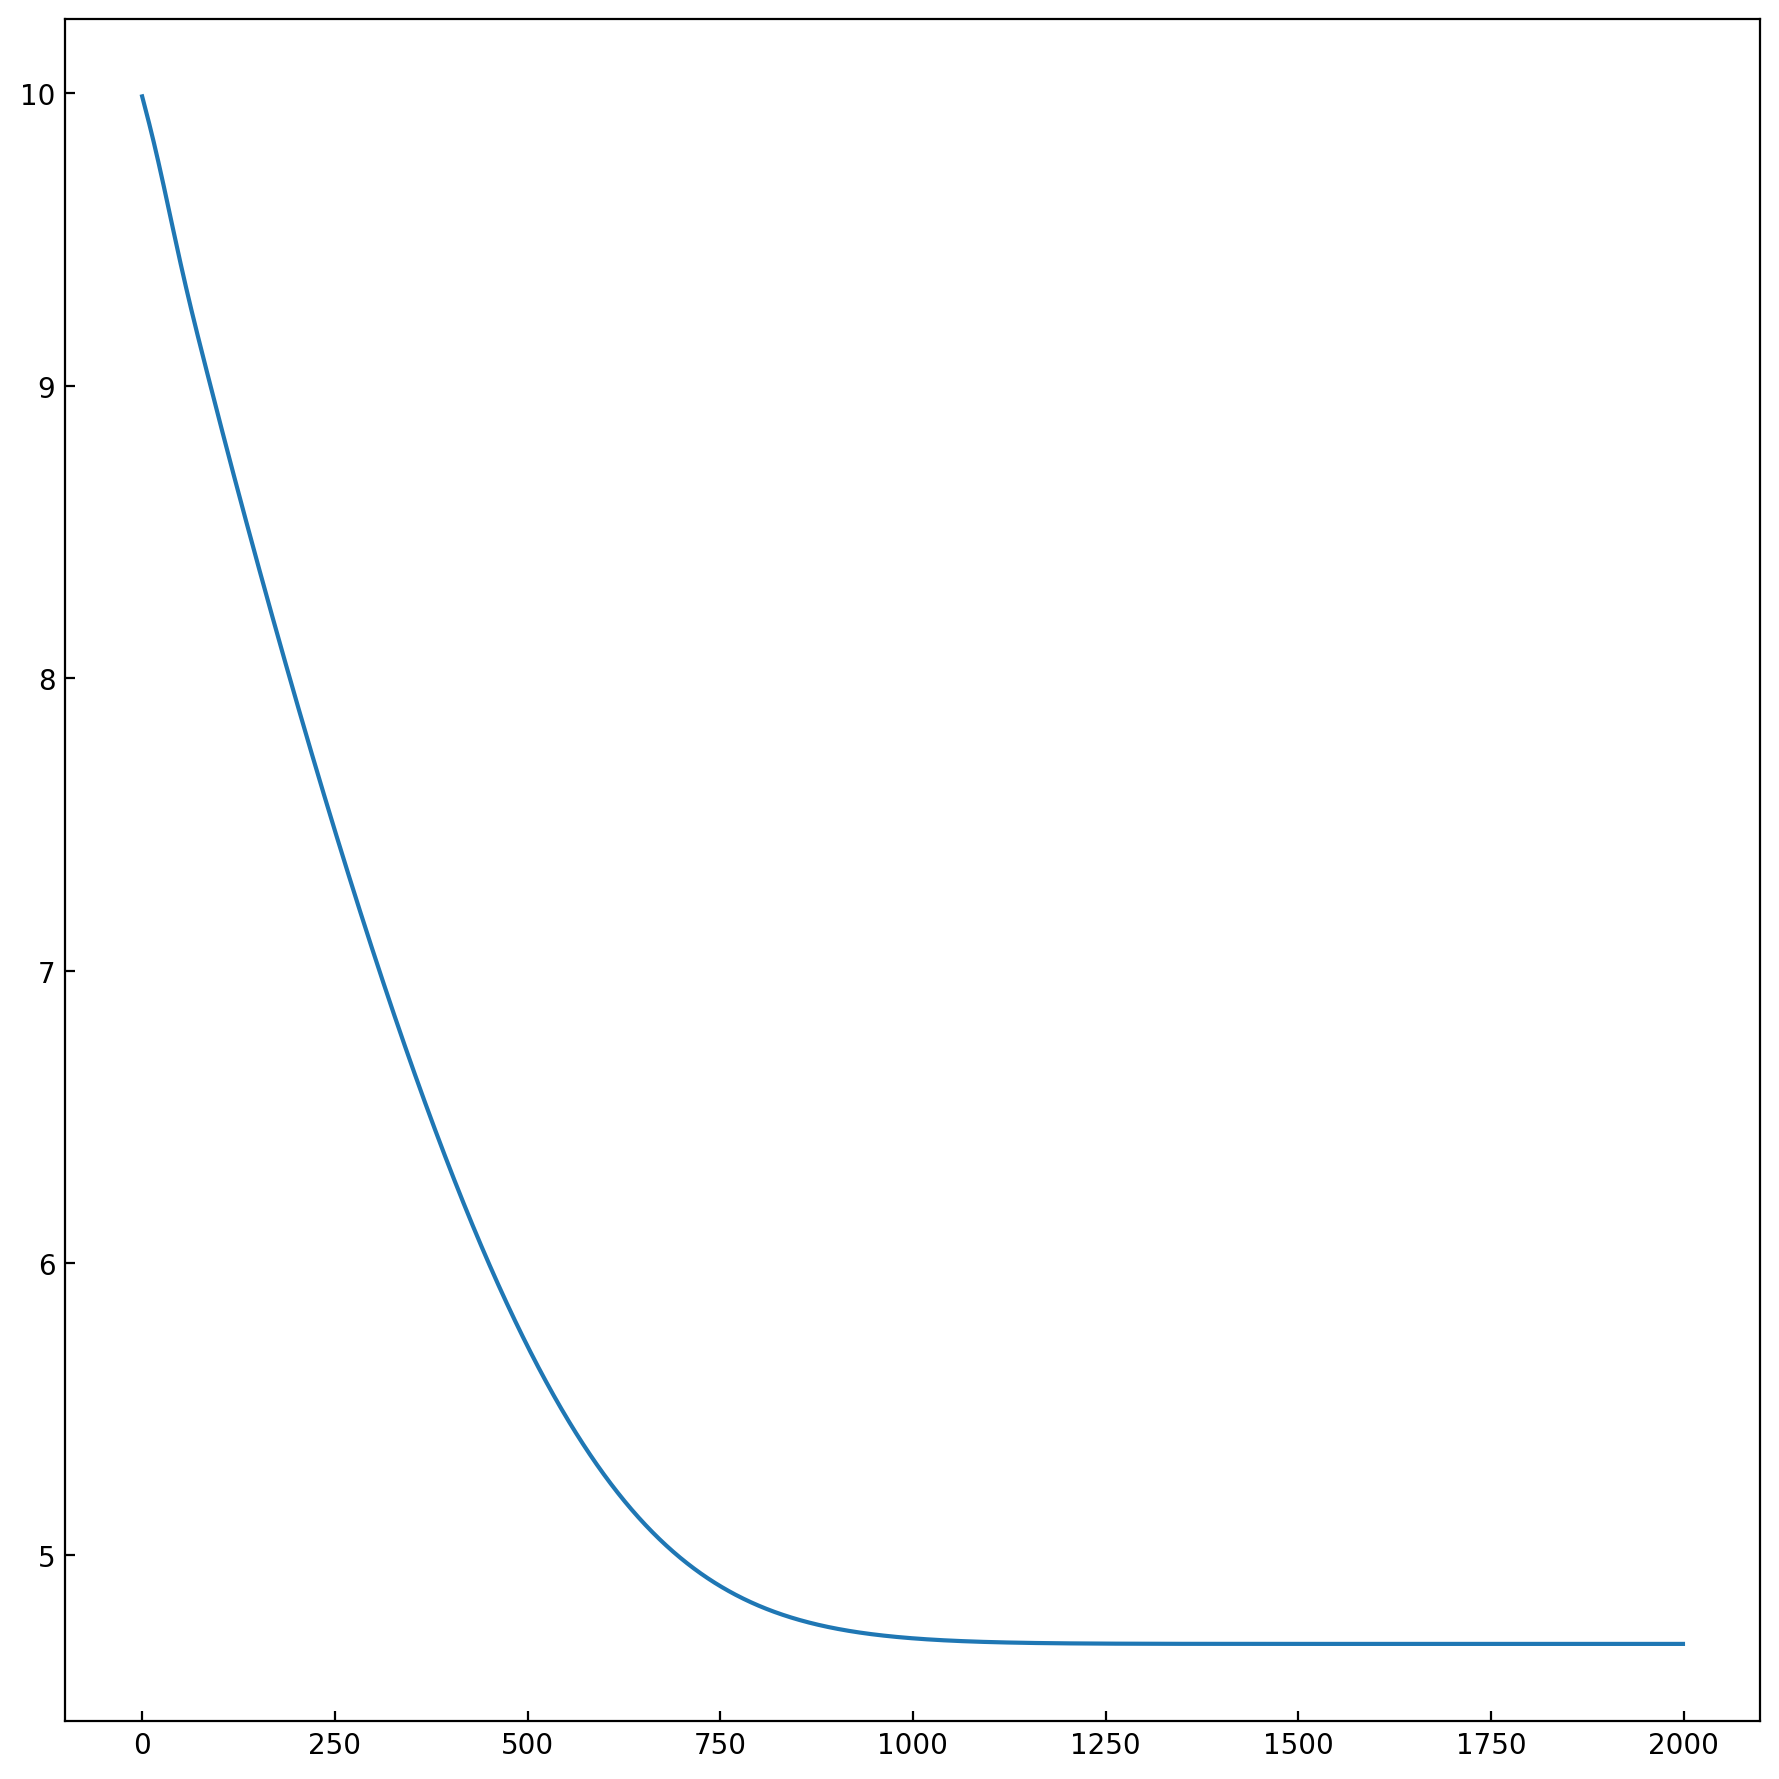

In [5]:
plt.plot(rs)

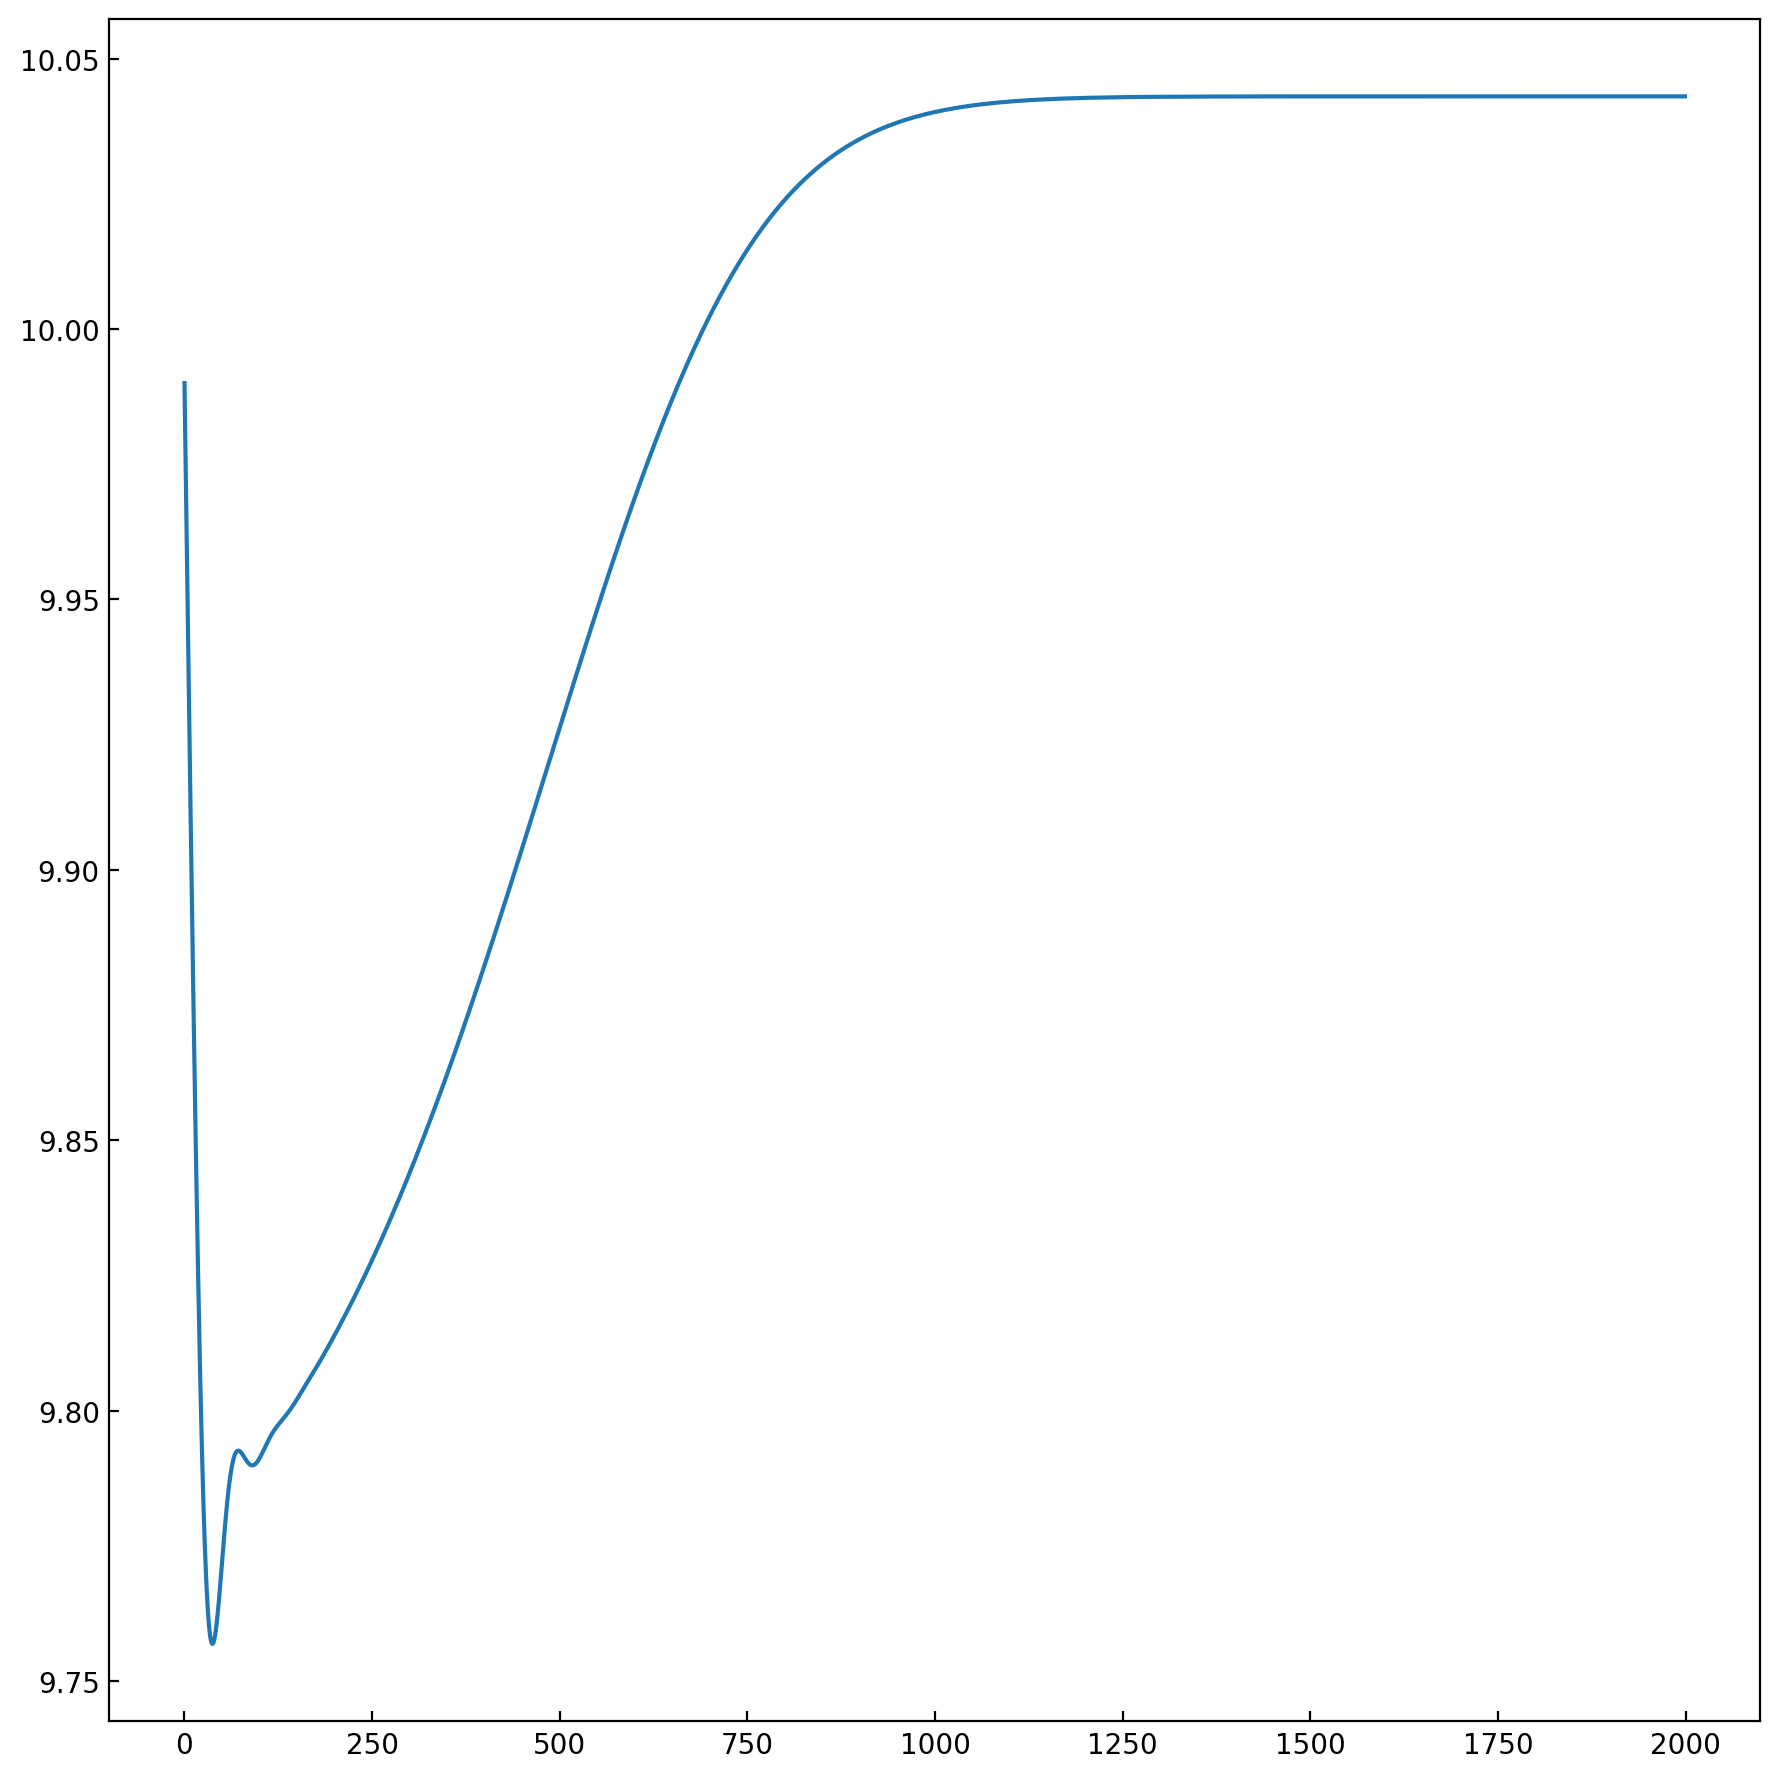

In [6]:
plt.plot(ms)

In [94]:
nb_grad2 = jax.jacrev(jax.scipy.stats.nbinom.logpmf, argnums=[2, 1])

print(nb_grad2(data[:1], true_r, true_r / (true_m + true_r)))
print(log_negative_binomial2_jac(data[:1], true_m, true_r))

(Array([9.], dtype=float32, weak_type=True), Array([-0.4640894], dtype=float32, weak_type=True))
[[ 9.         -0.46408848]]


In [79]:
true_r/true_p  -  data[0]/(1-true_p)

12.0

In [9]:
true_mean = nb_mean(true_r, true_p)
true_variance = nb_var(true_r, true_p)
print(true_mean, true_variance)
print(nb_mean(10., 10. / (10. + 10.)), nb_var(10., 10. / (10. + 10.)))

10.000000000000002 30.000000000000007
10.0 20.0


-941.4063245201828 -941.40625


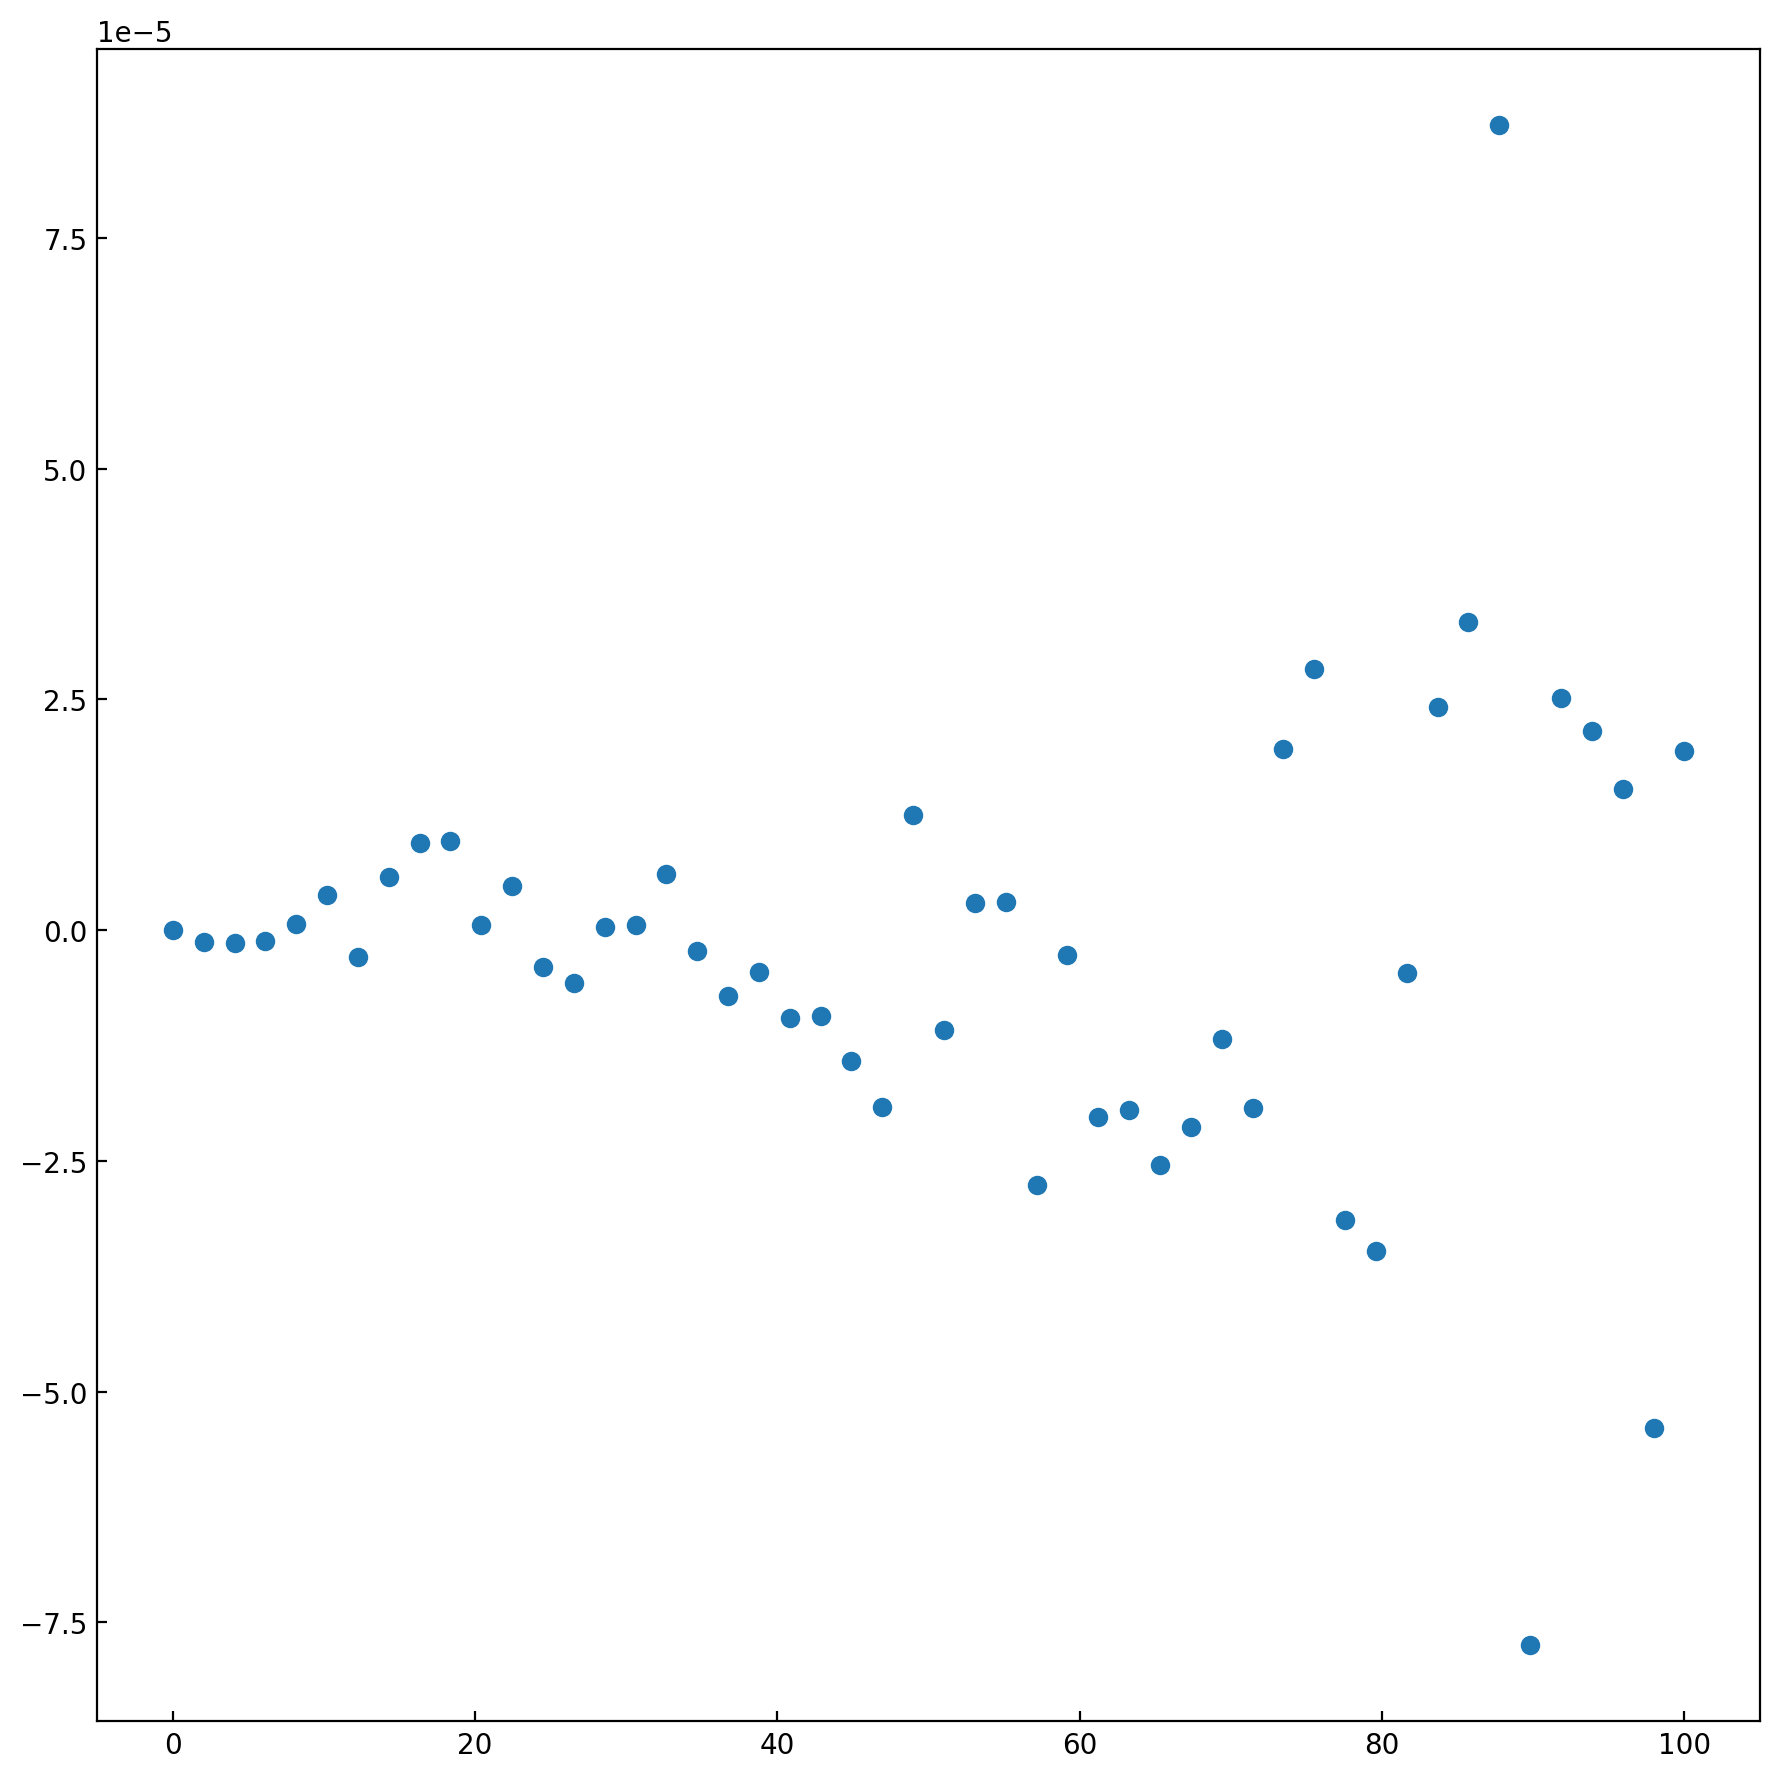

In [10]:
r = 10. + 1.4
m = 10. + 1.4
p = r / (r + m)
ks = np.linspace(0, 100, 50).astype(np.int32)
a = log_negative_binomial2(ks, m, r)
b = np.array([jax.scipy.stats.nbinom.logpmf(int(k), r, p) for k in np.linspace(0, 100, 50)])
# plt.plot(np.linspace(0, 100, 50), a, 'o')
plt.plot(np.linspace(0, 100, 50), a - b, 'o')

print(np.sum(a), np.sum(b))

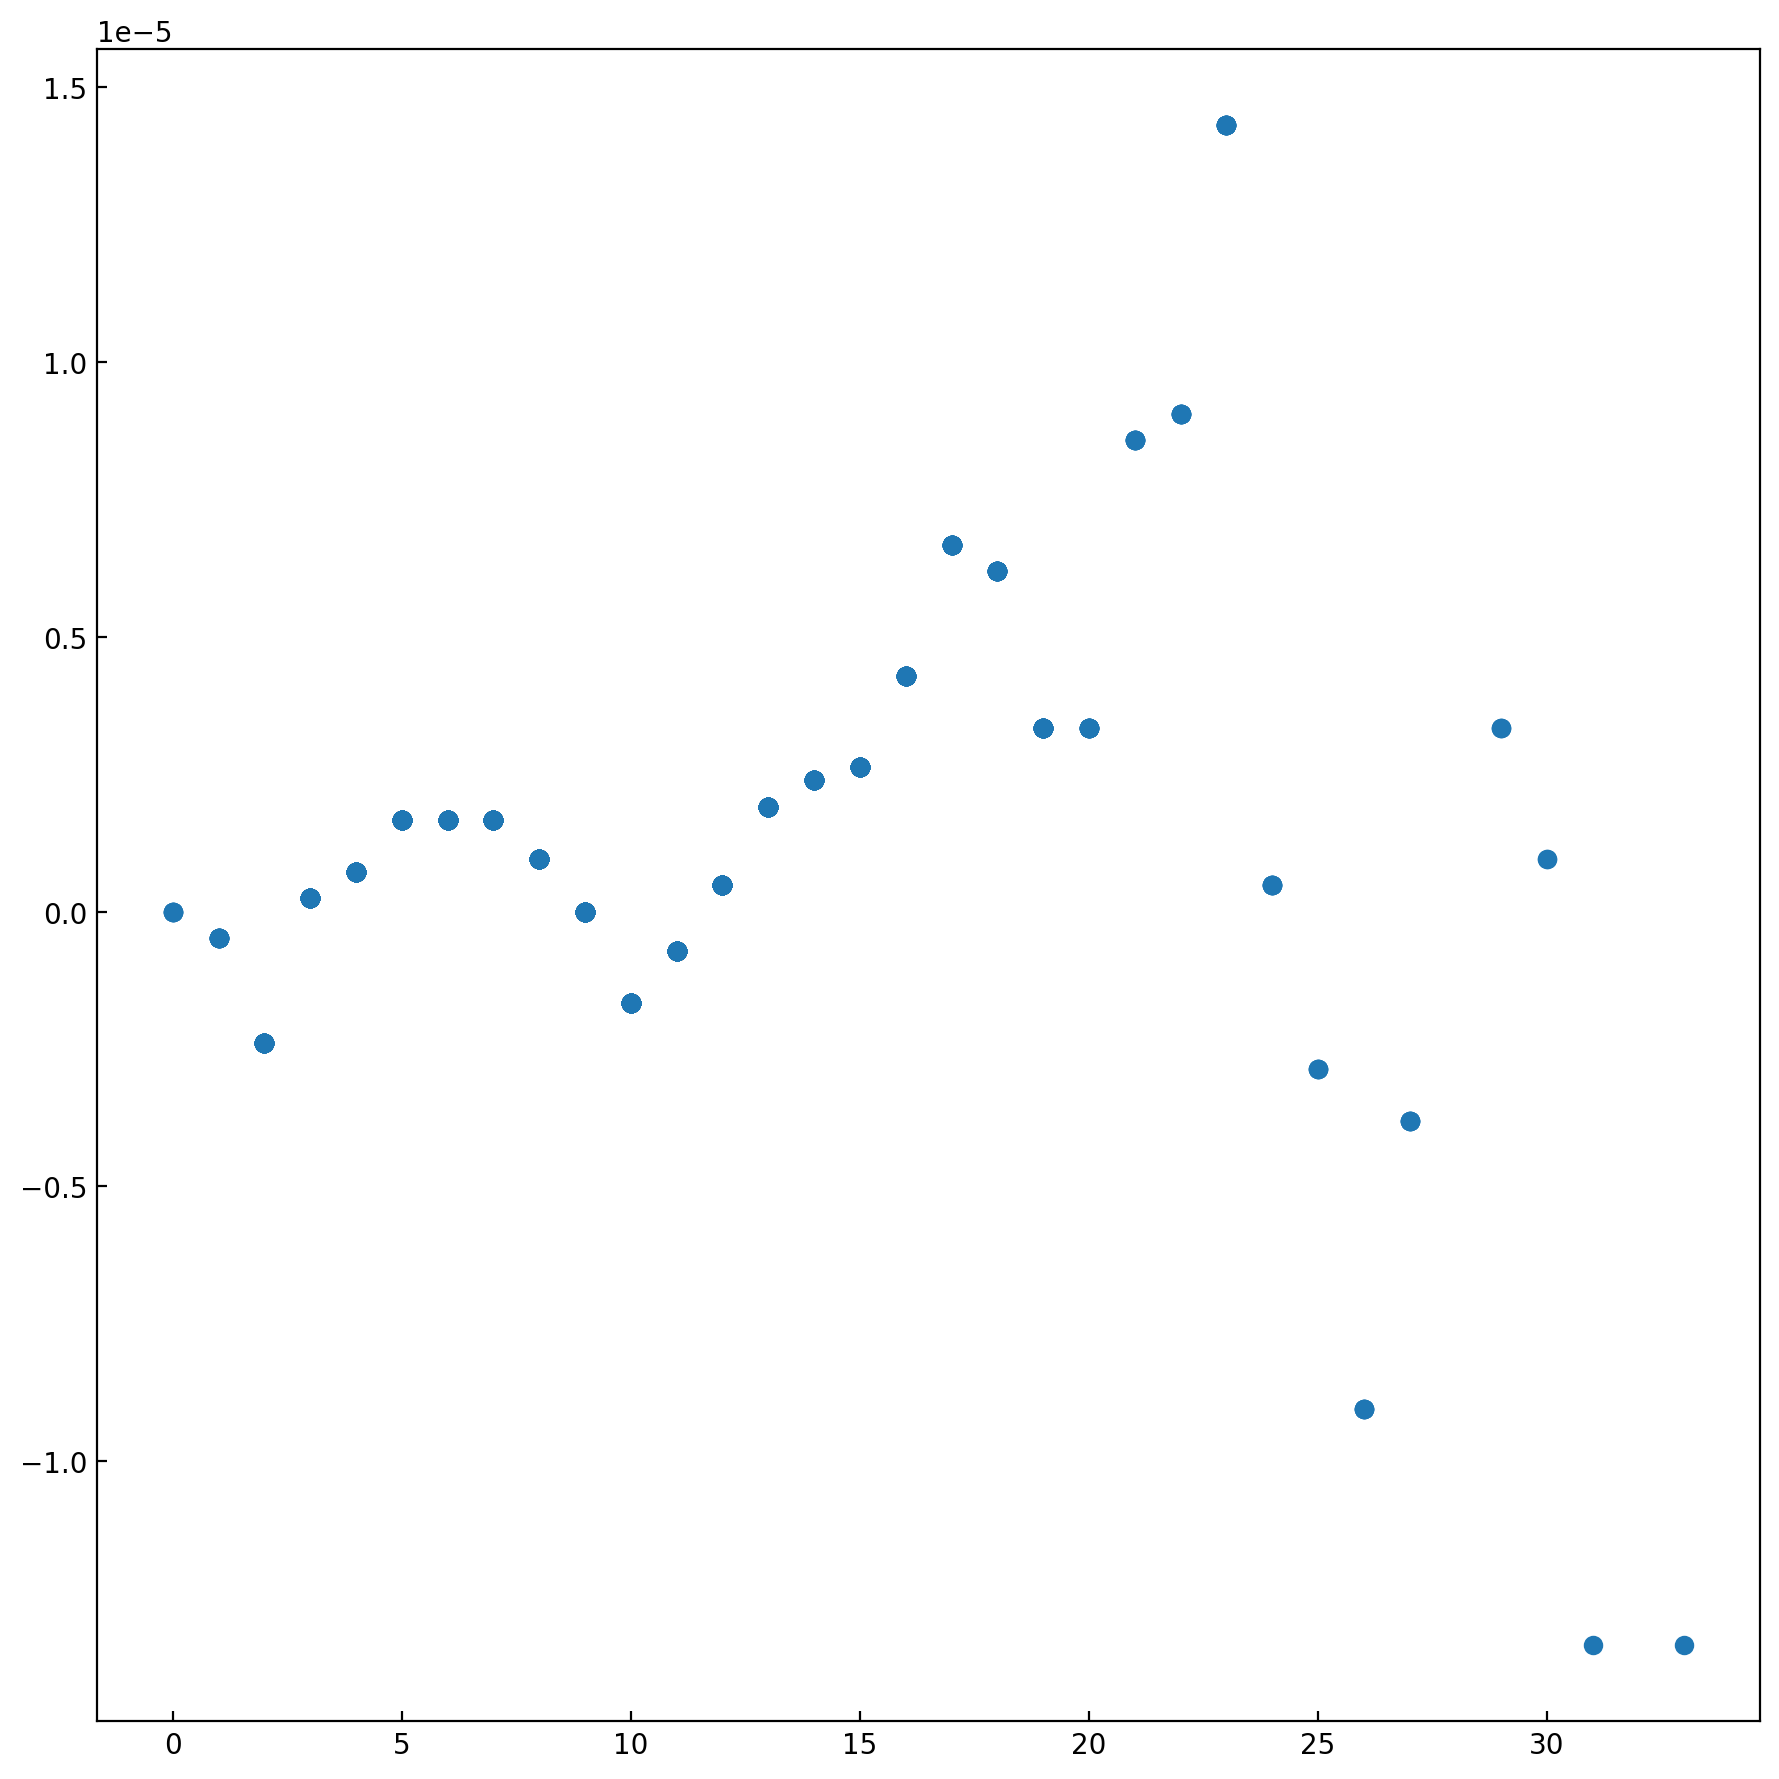

In [11]:
r = 10. - 1.1
m = 10.
p = r / (r + m)
a = np.array(log_negative_binomial2(data, m, r))
b = jax.scipy.stats.nbinom.logpmf(data, r, p)
# plt.plot(np.exp(a))
# plt.plot(np.exp(b))
plt.plot(data, a - b, 'o')
# print(np.sum(a), jnp.sum(b))

In [109]:
import jax
import jax.numpy as jnp
import numpy as np
from scipy.stats import nbinom
import optax
from tqdm import tqdm

from fast_negative_binomial import log_negative_binomial2, log_negative_binomial2_jac

def loss(params, data):
    m, r = params  # Direct parameters; assume r, m > 0
    log_pmf = log_negative_binomial2(data, m, r)
    return -jnp.sum(log_pmf)

def grad_loss(params, data):
    m, r = params

    loss_val = loss(params, data)

    dp_dm = -r / (m + r) ** 2

    jac = log_negative_binomial2_jac(data, m, r)
    jac[:, 0] *= dp_dm

    grads = jnp.mean(jac, axis = 0)

    return -grads, loss_val

def fit_negative_binomial(data, tol=1e-4, max_iters=1000, lr=1e-2):

    optimizer = optax.adam(lr)

    init_params = jnp.array([10., 10.])  # [m, r]
    opt_state = optimizer.init(init_params)
    params = init_params

    def step(params, opt_state, data):
        grads, loss_val = grad_loss(params, data)
        updates, opt_state = optimizer.update(grads, opt_state, params)
        params = optax.apply_updates(params, updates)
        return params, opt_state, loss_val

    # Optimization loop.
    for i in range(max_iters):
        params, opt_state, cur_loss = step(params, opt_state, data)
        if cur_loss < tol:
            print(f"Convergence reached at iteration {i} with loss {cur_loss:.6f}")
            break
    else:
        print(f"Maximum iterations reached with loss {cur_loss:.6f}")

    m, r = params
    return m, r, cur_loss

In [110]:
# Generate sample data from a negative binomial distribution.
true_r, true_m = 5.0, 10.0
true_p = true_r / (true_r + true_m)
data = nbinom.rvs(true_r, true_p, size=1000).astype(np.int32)

# Fit the model.
fitted_m, fitted_r, final_loss = fit_negative_binomial(data, tol=1e-2, max_iters=1000, lr=1e-2)
print(f"Fitted parameters: m = {fitted_m:.3f}, r = {fitted_r:.3f}, final loss = {final_loss:.6f}")

Maximum iterations reached with loss 3050.362793
Fitted parameters: m = 9.999, r = 4.891, final loss = 3050.362793
